In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PIPELINE_DIR = PROJECT_ROOT / "hr_pipeline"
if str(PIPELINE_DIR) not in sys.path:
    sys.path.insert(0, str(PIPELINE_DIR))

from clean import clean_all_sources, standardize_name_series
from config import CONFIG
from dedup import (
    deduplicate_employees,
    detect_ghost_employees,
    pass1_exact_id_match,
    pass2_email_match,
    pass3_fuzzy_name_match,
)
from export import (
    build_schema_frame,
    export_final_artifacts,
)
from ingest import ingest_all_sources
from validate import (
    QualityGateError,
    enforce_quality_gate,
    run_quality_checks,
)
from visualize import generate_eda_report

PROJECT_ROOT

PosixPath('/Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone')

In [2]:
# Configured project directories
pd.Series({
    "raw_data": CONFIG["input_dir"],
    "processed_data": CONFIG["output_dir"],
    "dead_letters": CONFIG["dead_letter_dir"],
    "logs": CONFIG["log_dir"],
}, name="path")

raw_data          /Users/amalitech-pc-10512/Documents/GitHub/DE-...
processed_data    /Users/amalitech-pc-10512/Documents/GitHub/DE-...
dead_letters      /Users/amalitech-pc-10512/Documents/GitHub/DE-...
logs              /Users/amalitech-pc-10512/Documents/GitHub/DE-...
Name: path, dtype: object

In [3]:
# Input file inventory
input_inventory = pd.DataFrame([
    {
        "source_system": source,
        "filename": path.name,
        "format": path.suffix,
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / 1_000_000, 2) if path.exists() else pd.NA,
    }
    for source, path in CONFIG["input_files"].items()
])
input_inventory

,source_system,filename,format,exists,size_mb
0,globaltech_hris,globaltech_hris.csv,.csv,True,1.69
1,acquiredco_hris,acquiredco_api.json,.json,True,1.76
2,payroll,payroll_data.xlsx,.xlsx,True,0.74
3,benefits,benefits_enrollment.xml,.xml,True,3.58


In [4]:
# Standard schema shared by all ingested source frames
pd.DataFrame({
    "position": range(1, len(CONFIG["standard_schema"]) + 1),
    "column": CONFIG["standard_schema"],
})

,position,column
0,1,employee_id
1,2,first_name
2,3,last_name
3,4,email
4,5,department
5,6,job_title
6,7,hire_date
7,8,country
8,9,employment_type
9,10,employment_status


In [5]:
# Cleaning and matching business rules
print("Exchange rates to USD:", CONFIG["exchange_rates_to_usd"])
print("Annual multipliers:", CONFIG["pay_frequency_multipliers"])
print("Employment types:", CONFIG["valid_employment_types"])
print("Fuzzy threshold:", CONFIG["fuzzy_match_threshold"])
print("Hire-date window:", CONFIG["fuzzy_hire_date_window_days"], "days")

Exchange rates to USD: {'USD': 1.0, 'EUR': 1.09, 'GBP': 1.27}
Annual multipliers: {'Annual': 1, 'Monthly': 12, 'Bi-Weekly': 26}
Employment types: ['Full-Time', 'Part-Time', 'Contractor']
Fuzzy threshold: 88
Hire-date window: 30 days


In [6]:
# Deliverable 1: ingest all four source systems
raw_frames = ingest_all_sources()

2026-07-23 12:17:55,693 [INFO] globaltech_hr_pipeline: ============================================================
2026-07-23 12:17:55,694 [INFO] globaltech_hr_pipeline: STEP 1: Multi-source ingestion
2026-07-23 12:17:55,694 [INFO] globaltech_hr_pipeline: Ingesting globaltech_hris CSV: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/raw/globaltech_hris.csv
2026-07-23 12:17:55,758 [INFO] globaltech_hr_pipeline: Ingested 15,000 records from globaltech_hris
2026-07-23 12:17:55,759 [INFO] globaltech_hr_pipeline: Ingesting acquiredco_hris JSON with simulated page size 100: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/raw/acquiredco_api.json
2026-07-23 12:17:55,767 [INFO] globaltech_hr_pipeline: Processed simulated page 1 (100 record(s))
2026-07-23 12:17:55,767 [INFO] globaltech_hr_pipeline: Processed simulated page 2 (100 record(s))
2026-07-23 12:17:55,767 [INFO] globaltech_hr_pipeline: Processed simulated page 3 (100 record(s))
2026-07-23

In [7]:
# Record counts and source tags after ingestion
ingestion_summary = pd.DataFrame([
    {
        "source_system": source,
        "records": len(frame),
        "columns": len(frame.columns),
        "tagged_correctly": int(frame["source_system"].eq(source).sum()),
        "company_origins": ", ".join(sorted(frame["company_origin"].dropna().astype(str).unique())),
    }
    for source, frame in raw_frames.items()
])
ingestion_summary

,source_system,records,columns,tagged_correctly,company_origins
0,globaltech_hris,15000,26,15000,GlobalTech
1,acquiredco_hris,3200,26,3200,AcquiredCo
2,payroll,19000,26,19000,"AcquiredCo, GlobalTech"
3,benefits,12000,26,12000,GlobalTech


In [8]:
# GlobalTech HRIS sample before cleaning
globaltech_raw = raw_frames["globaltech_hris"]
globaltech_raw[[
    "employee_id", "first_name", "last_name", "email", "department",
    "hire_date", "employment_type", "manager_id", "company_origin"
]].head()

,employee_id,first_name,last_name,email,department,hire_date,employment_type,manager_id,company_origin
0,1,Michael,King,michael.king@globaltech.com,Manufacturing,2016-09-21,Full-Time,12765,GlobalTech
1,2,David,Phillips,david.phillips@globaltech.com,Strategy,2022-02-06,Contractor,1662,GlobalTech
2,3,Kenneth,Martinez,kenneth.martinez@globaltech.com,Human Resources,2021-06-10,Contractor,6142,GlobalTech
3,4,Paul,Cooper,paul.cooper@globaltech.com,Human Resources,2024-09-07,Full-Time,5904,GlobalTech
4,5,Stephen,Parker,stephen.parker@globaltech.com,Marketing,2023-03-09,Part-Time,566,GlobalTech


In [9]:
# AcquiredCo HRIS sample before cleaning
acquiredco_raw = raw_frames["acquiredco_hris"]
acquiredco_raw[[
    "employee_id", "first_name", "last_name", "email", "department",
    "hire_date", "employment_type", "manager_id", "company_origin"
]].head()

,employee_id,first_name,last_name,email,department,hire_date,employment_type,manager_id,company_origin
0,ACQ_00001,Larry,Smith,larry.smith@acquiredco.com,Product,2024-06-27T00:00:00,PT,ACQ_02436,AcquiredCo
1,ACQ_00002,Michael,Crawford,michael.crawford@acquiredco.com,Legal,2021-06-09T00:00:00,PT,ACQ_02546,AcquiredCo
2,ACQ_00003,Brandon,Moore,brandon.moore@acquiredco.com,Marketing,2022-06-20T00:00:00,CONTRACTOR,ACQ_01415,AcquiredCo
3,ACQ_00004,Ashley,Moore,ashley.moore@acquiredco.com,Marketing,2022-04-27T00:00:00,CONTRACTOR,ACQ_01247,AcquiredCo
4,ACQ_00005,Rachel,Clark,rachel.clark@acquiredco.com,Sales,2017-05-01T00:00:00,PT,ACQ_02354,AcquiredCo


In [10]:
# Payroll and benefits samples before cleaning
payroll_raw = raw_frames["payroll"]
benefits_raw = raw_frames["benefits"]

display(payroll_raw[[
    "employee_id", "company_origin", "base_salary", "currency",
    "pay_frequency", "bonus_target_pct", "payroll_effective_date"
]].head())
display(benefits_raw[[
    "employee_id", "benefit_plans", "benefit_coverage_level",
    "benefit_enrollment_date", "premium_employee", "premium_employer"
]].head())

,employee_id,company_origin,base_salary,currency,pay_frequency,bonus_target_pct,payroll_effective_date
0,14571,GlobalTech,77935,EUR,Monthly,24.50,2023-05-12
1,12628,GlobalTech,119344,EUR,Bi-Weekly,2.80,2024-08-02
2,12173,GlobalTech,67963,GBP,Annual,5.90,2023-10-12
3,8747,GlobalTech,101292,EUR,Monthly,17.90,2023-06-15
4,1729,GlobalTech,95986,GBP,Monthly,26.60,2023-06-28


,employee_id,benefit_plans,benefit_coverage_level,benefit_enrollment_date,premium_employee,premium_employer
0,2239,Vision,Family,2024-03-23,54.5,469.17
1,7612,401(k),Employee+Spouse,2021-06-14,188.19,705.57
2,12967,Life Insurance,Employee+Child,2020-07-26,63.5,261.07
3,12133,Health Insurance,Employee+Child,2024-05-25,213.74,875.07
4,14962,Life Insurance,Individual,2024-08-04,272.75,911.8


In [11]:
# Deliverable 2: run all cleaning and transformation functions
cleaned_frames = clean_all_sources(raw_frames)

2026-07-23 12:17:57,330 [INFO] globaltech_hr_pipeline: ============================================================
2026-07-23 12:17:57,331 [INFO] globaltech_hr_pipeline: STEP 2: Data cleaning and transformation
2026-07-23 12:17:57,543 [INFO] globaltech_hr_pipeline: Cleaned globaltech_hris 15,000 record(s)
2026-07-23 12:17:57,606 [INFO] globaltech_hr_pipeline: Cleaned acquiredco_hris 3,200 record(s)
2026-07-23 12:17:57,809 [INFO] globaltech_hr_pipeline: Cleaned payroll 19,000 record(s)
2026-07-23 12:17:57,948 [INFO] globaltech_hr_pipeline: Cleaned benefits 12,000 record(s)
2026-07-23 12:17:57,954 [INFO] globaltech_hr_pipeline: Unmapped department review: 0 value(s) written to /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/unmapped_departments.csv
2026-07-23 12:17:57,954 [INFO] globaltech_hr_pipeline: Annualized 19,000 payroll salary record(s)


In [12]:
# Unicode, whitespace, apostrophe, hyphen, and multi-word name examples
name_examples = pd.Series(
    [" josé ", "o'BRIEN", "van  der berg", "anne-mARIE"],
    name="source_name",
)
pd.DataFrame({
    "source_name": name_examples,
    "standardized_name": standardize_name_series(name_examples),
})

,source_name,standardized_name
0,josé,José
1,o'BRIEN,O'Brien
2,van der berg,Van Der Berg
3,anne-mARIE,Anne-Marie


In [13]:
# Employee and manager IDs before and after namespacing
id_comparison = pd.concat([
    cleaned_frames["globaltech_hris"][[
        "company_origin", "employee_id_raw", "employee_id", "manager_id_raw", "manager_id"
    ]].head(5),
    cleaned_frames["acquiredco_hris"][[
        "company_origin", "employee_id_raw", "employee_id", "manager_id_raw", "manager_id"
    ]].head(5),
], ignore_index=True)
id_comparison

,company_origin,employee_id_raw,employee_id,manager_id_raw,manager_id
0,GlobalTech,1,GT-000001,12765,GT-012765
1,GlobalTech,2,GT-000002,1662,GT-001662
2,GlobalTech,3,GT-000003,6142,GT-006142
3,GlobalTech,4,GT-000004,5904,GT-005904
4,GlobalTech,5,GT-000005,566,GT-000566
5,AcquiredCo,ACQ_00001,AC-000001,ACQ_02436,AC-002436
6,AcquiredCo,ACQ_00002,AC-000002,ACQ_02546,AC-002546
7,AcquiredCo,ACQ_00003,AC-000003,ACQ_01415,AC-001415
8,AcquiredCo,ACQ_00004,AC-000004,ACQ_01247,AC-001247
9,AcquiredCo,ACQ_00005,AC-000005,ACQ_02354,AC-002354


In [14]:
# Employment type values before and after taxonomy mapping
print("Before:")
display(
    raw_frames["acquiredco_hris"]["employment_type"]
    .value_counts()
    .rename("records")
)
print("After:")
cleaned_frames["acquiredco_hris"]["employment_type"].value_counts().rename("records")

Before:


employment_type
PT            1102
CONTRACTOR    1071
FT            1027
Name: records, dtype: int64

After:


employment_type
Part-Time     1102
Contractor    1071
Full-Time     1027
Name: records, dtype: Int64

In [15]:
# Original salary fields retained alongside the derived annual USD salary
payroll_clean = cleaned_frames["payroll"]
symbol_salary = payroll_clean["base_salary"].astype("string").str.contains(
    r"[$£€]", regex=True, na=False
)
payroll_clean.loc[symbol_salary, [
    "employee_id", "base_salary", "currency", "pay_frequency", "salary_usd_annual"
]].head(15)

,employee_id,base_salary,currency,pay_frequency,salary_usd_annual
40,GT-014575,"$70,315",USD,Monthly,"843,780.00"
96,GT-008431,"$148,832",USD,Bi-Weekly,"3,869,632.00"
165,GT-013414,"£140,888",GBP,Annual,"178,927.76"
188,GT-012764,"£96,012",GBP,Monthly,"1,463,222.88"
258,GT-001533,"£140,418",GBP,Annual,"178,330.86"
270,GT-002972,"£54,153",GBP,Bi-Weekly,"1,788,132.06"
337,GT-003768,"£100,018",GBP,Bi-Weekly,"3,302,594.36"
355,GT-005673,"£67,231",GBP,Monthly,"1,024,600.44"
364,GT-000112,"£110,570",GBP,Monthly,"1,685,086.80"
369,GT-013916,"€118,496",EUR,Annual,"129,160.64"


In [16]:
# Annual USD salary distribution by source currency and pay frequency
payroll_clean.groupby(["currency", "pay_frequency"])["salary_usd_annual"].agg(
    records="count",
    minimum="min",
    median="median",
    mean="mean",
    maximum="max",
).round(2)

records      minimum       median         mean  \
currency pay_frequency                                                   
EUR      Annual            2189    50,303.50   106,639.06   108,888.60   
         Bi-Weekly         2068 1,303,838.38 2,781,032.54 2,808,760.82   
         Monthly           2131   602,281.68 1,301,486.16 1,314,719.18   
GBP      Annual            2121    50,827.94   110,111.54   111,023.28   
         Bi-Weekly         2107 1,322,484.02 2,829,814.00 2,869,605.59   
         Monthly           2112   609,904.80 1,307,774.88 1,324,113.70   
USD      Annual            2118    50,209.00   105,609.00   106,948.42   
         Bi-Weekly         2001 1,301,612.00 2,767,076.00 2,814,961.30   
         Monthly           2153   600,132.00 1,293,684.00 1,301,934.57   

                            maximum  
currency pay_frequency               
EUR      Annual          248,526.54  
         Bi-Weekly     6,491,560.40  
         Monthly       3,001,035.96  
GBP      Annual          253,954.28  
         Bi-Weekly     6,602,976.38  
         Monthly       3,015,279.72  
USD      Annual          246,559.00  
         Bi-Weekly     6,487,234.00  
         Monthly       2,994,144.00

In [17]:
# Standard department counts after taxonomy mapping
hris_clean = pd.concat([
    cleaned_frames["globaltech_hris"],
    cleaned_frames["acquiredco_hris"],
], ignore_index=True)
hris_clean["department"].value_counts(dropna=False).rename("employees")

department
Customer Success          1038
Strategy                  1035
Human Resources           1021
Marketing                 1018
Data Science              1018
Communications            1012
Legal                     1012
Engineering               1011
Business Development      1010
Product                   1008
Manufacturing             1006
Quality Assurance         1003
Sales                      999
DevOps                     995
Information Technology     991
Operations                 990
Finance                    987
Supply Chain               982
<NA>                        64
Name: employees, dtype: Int64

In [18]:
# Values requiring manual department review
unmapped_path = CONFIG["output_files"]["unmapped_departments"]
unmapped_departments = pd.read_csv(unmapped_path)
print(f"Unmapped department values: {len(unmapped_departments)}")
unmapped_departments

Unmapped department values: 0


,source_system,company_origin,department_original,record_count


In [19]:
# Parsed date ranges, dtypes, and invalid-value flags
date_summary = []
for source, frame in cleaned_frames.items():
    for column in ("hire_date", "payroll_effective_date", "benefit_enrollment_date"):
        flag = f"{column}_invalid"
        if frame[column].notna().any():
            date_summary.append({
                "source_system": source,
                "column": column,
                "dtype": str(frame[column].dtype),
                "parsed": int(frame[column].notna().sum()),
                "invalid": int(frame[flag].sum()),
                "minimum": frame[column].min(),
                "maximum": frame[column].max(),
            })
pd.DataFrame(date_summary)

,source_system,column,dtype,parsed,invalid,minimum,maximum
0,globaltech_hris,hire_date,datetime64[ns],15000,0,2015-01-01,2024-12-31
1,acquiredco_hris,hire_date,datetime64[ns],3200,0,2015-01-03,2024-12-30
2,payroll,payroll_effective_date,datetime64[ns],19000,0,2023-01-01,2024-12-31
3,benefits,benefit_enrollment_date,datetime64[ns],12000,0,2020-01-01,2024-12-31


In [20]:
# Stage-level reconciliation and derived-value coverage
stage_summary = pd.DataFrame([
    {
        "source_system": source,
        "ingested_records": len(raw_frames[source]),
        "cleaned_records": len(cleaned),
        "canonical_employee_ids": int(cleaned["employee_id"].str.match(CONFIG["employee_id_regex"], na=False).sum()),
        "annual_usd_salaries": int(cleaned["salary_usd_annual"].notna().sum()),
        "invalid_dates": sum(
            int(cleaned[column].sum())
            for column in cleaned.columns
            if column.endswith("_date_invalid")
        ),
    }
    for source, cleaned in cleaned_frames.items()
])
stage_summary

,source_system,ingested_records,cleaned_records,canonical_employee_ids,annual_usd_salaries,invalid_dates
0,globaltech_hris,15000,15000,15000,0,0
1,acquiredco_hris,3200,3200,3200,0,0
2,payroll,19000,19000,19000,19000,0
3,benefits,12000,12000,12000,0,0


In [21]:
# Dead-letter history from ingestion failures or malformed records
dead_letter_files = sorted(CONFIG["dead_letter_dir"].glob("*_dead_letters.csv"))
if dead_letter_files:
    dead_letter_summary = pd.DataFrame([
        {
            "file": path.name,
            "recorded_failures": len(pd.read_csv(path)),
            "latest_reason": pd.read_csv(path).iloc[-1]["reason"],
        }
        for path in dead_letter_files
    ])
else:
    dead_letter_summary = pd.DataFrame(columns=["file", "recorded_failures", "latest_reason"])
dead_letter_summary

,file,recorded_failures,latest_reason
0,payroll_dead_letters.csv,1,ImportError: Missing optional dependency 'open...


In [22]:
# Cleaning checkpoint before deduplication
print(f"Sources processed: {len(cleaned_frames)}")
print(f"Total source records: {sum(len(frame) for frame in cleaned_frames.values()):,}")
print(f"HRIS employee records: {len(hris_clean):,}")
print(f"Payroll salaries annualized: {payroll_clean['salary_usd_annual'].notna().sum():,}")
print(
    "Dedup rules — fuzzy threshold:",
    CONFIG["fuzzy_match_threshold"],
    "| hire-date window:",
    CONFIG["fuzzy_hire_date_window_days"],
    "days",
)

Sources processed: 4
Total source records: 49,200
HRIS employee records: 18,200
Payroll salaries annualized: 19,000
Dedup rules — fuzzy threshold: 88 | hire-date window: 30 days


In [23]:
# Deliverable 3 / Pass 1: exact employee ID match
# HRIS is the spine; payroll and benefits enrich matching namespaced IDs.
employees_pass1 = pass1_exact_id_match(cleaned_frames)

pass1_summary = pd.DataFrame([
    {
        "metric": "input_hris_rows",
        "value": len(cleaned_frames["globaltech_hris"]) + len(cleaned_frames["acquiredco_hris"]),
    },
    {"metric": "pass1_employees", "value": len(employees_pass1)},
    {
        "metric": "exact_id_merges",
        "value": int(employees_pass1["dedup_method"].eq("exact_id").sum()),
    },
    {
        "metric": "single_source",
        "value": int(employees_pass1["dedup_method"].eq("single_source").sum()),
    },
    {
        "metric": "with_payroll",
        "value": int(employees_pass1["source_systems"].astype("string").str.contains("payroll", na=False).sum()),
    },
    {
        "metric": "with_benefits",
        "value": int(employees_pass1["source_systems"].astype("string").str.contains("benefits", na=False).sum()),
    },
])
pass1_summary

2026-07-23 12:17:58,318 [INFO] globaltech_hr_pipeline: Collapsed HRIS 18,200 rows -> 18,001 unique employee IDs
2026-07-23 12:18:02,214 [INFO] globaltech_hr_pipeline: Pass 1 exact ID match: 18,001 HRIS employees enriched with payroll/benefits


,metric,value
0,input_hris_rows,18200
1,pass1_employees,18001
2,exact_id_merges,14692
3,single_source,3309
4,with_payroll,11139
5,with_benefits,8283


In [24]:
# Pass 1 enrichment samples: one employee joined across HRIS, payroll, and benefits
multi_source = employees_pass1.loc[
    employees_pass1["source_systems"].astype("string").str.contains(",", na=False)
]
multi_source[[
    "employee_id",
    "first_name",
    "last_name",
    "company_origin",
    "source_systems",
    "dedup_method",
    "salary_usd_annual",
    "benefits_enrolled",
    "benefit_plan_count",
]].head(10)

,employee_id,first_name,last_name,company_origin,source_systems,dedup_method,salary_usd_annual,benefits_enrolled,benefit_plan_count
1,AC-000001,Larry,Smith,AcquiredCo,"acquiredco_hris,payroll",exact_id,"727,588.08",False,0
2,AC-000002,Michael,Crawford,AcquiredCo,"acquiredco_hris,payroll",exact_id,"1,194,846.48",False,0
3,AC-000003,Brandon,Moore,AcquiredCo,"acquiredco_hris,payroll",exact_id,"2,572,752.00",False,0
4,AC-000004,Ashley,Moore,AcquiredCo,"acquiredco_hris,payroll",exact_id,"134,360.92",False,0
6,AC-000006,Ruth,Perez,AcquiredCo,"acquiredco_hris,payroll",exact_id,"51,088.29",False,0
7,AC-000007,Jonathan,Reed,AcquiredCo,"acquiredco_hris,payroll",exact_id,"847,191.60",False,0
8,AC-000008,Charles,Bennett,AcquiredCo,"acquiredco_hris,payroll",exact_id,"1,304,422.08",False,0
9,AC-000009,Michael,Mason,AcquiredCo,"acquiredco_hris,payroll",exact_id,"134,778.50",False,0
10,AC-000010,Nicole,Reyes,AcquiredCo,"acquiredco_hris,payroll",exact_id,"1,226,642.40",False,0
11,AC-000011,Ruth,Dixon,AcquiredCo,"acquiredco_hris,payroll",exact_id,"123,088.25",False,0


In [25]:
# Ghost employees: payroll IDs with no matching HRIS record after Pass 1
ghosts = detect_ghost_employees(
    cleaned_frames["payroll"],
    set(employees_pass1["employee_id"].dropna().astype(str)),
)
print(f"Ghost employee records: {len(ghosts):,}")
ghosts.head(10) if not ghosts.empty else ghosts

Ghost employee records: 0


,payroll_employee_id,name,salary_usd_annual,ghost_flag_reason,ghost_employee,company_origin,source_system


In [26]:
# Deliverable 3 / Pass 2: cross-company email match
employees_pass2 = pass2_email_match(employees_pass1)

email_matches = employees_pass2.loc[employees_pass2["dedup_method"].eq("email_match")]
pass2_summary = pd.Series({
    "employees_before": len(employees_pass1),
    "employees_after": len(employees_pass2),
    "rows_collapsed": len(employees_pass1) - len(employees_pass2),
    "email_match_employees": len(email_matches),
}, name="pass2")
display(pass2_summary)

email_matches[[
    "employee_id",
    "first_name",
    "last_name",
    "email",
    "company_origin",
    "source_systems",
    "dedup_method",
]].head(10) if not email_matches.empty else email_matches

2026-07-23 12:18:02,297 [INFO] globaltech_hr_pipeline: Pass 2 email match: 0 cross-company email collisions


employees_before         18001
employees_after          18001
rows_collapsed               0
email_match_employees        0
Name: pass2, dtype: int64

,employee_id,first_name,last_name,email,department,job_title,hire_date,country,employment_type,employment_status,manager_id,company_origin,source_system,employee_id_raw,manager_id_raw,department_original,department_unmapped,hire_date_invalid,payroll_effective_date_invalid,benefit_enrollment_date_invalid,source_systems,dedup_method,base_salary,currency,pay_frequency,bonus_target_pct,payroll_effective_date,salary_usd_annual,benefits_enrolled,benefit_plans,benefit_plan_count,benefit_coverage_level,benefit_enrollment_date,premium_employee,premium_employer


In [27]:
# Deliverable 3 / Pass 3: fuzzy name match for HR review (no auto-merge)
probable_matches = pass3_fuzzy_name_match(employees_pass2)

print(
    f"Probable match pairs: {len(probable_matches):,} "
    f"(threshold={CONFIG['fuzzy_match_threshold']}%, "
    f"window={CONFIG['fuzzy_hire_date_window_days']} days)"
)
probable_matches[[
    "record_1_id",
    "record_2_id",
    "record_1_name",
    "record_2_name",
    "record_1_company",
    "record_2_company",
    "similarity_score",
    "hire_date_diff_days",
    "recommended_action",
]].head(15) if not probable_matches.empty else probable_matches

2026-07-23 12:18:08,887 [INFO] globaltech_hr_pipeline: Pass 3 fuzzy name match: 113 probable pair(s) for HR review (threshold=88%, window=30 days)


Probable match pairs: 113 (threshold=88%, window=30 days)


,record_1_id,record_2_id,record_1_name,record_2_name,record_1_company,record_2_company,similarity_score,hire_date_diff_days,recommended_action
0,GT-007166,AC-000000,John Allen,John Allen,GlobalTech,AcquiredCo,100.00,0,review
1,GT-005191,AC-002393,Janet Young,Janet Young,GlobalTech,AcquiredCo,100.00,0,review
2,GT-014913,AC-000199,Mary Mason,Mary Mason,GlobalTech,AcquiredCo,100.00,0,review
3,GT-001274,AC-001262,Donald Russell,Donald Russell,GlobalTech,AcquiredCo,100.00,0,review
4,AC-002737,GT-003960,Richard Boyd,Richard Boyd,AcquiredCo,GlobalTech,100.00,1,review
5,GT-009376,AC-001667,Kenneth Lee,Kenneth Lee,GlobalTech,AcquiredCo,100.00,1,review
6,AC-001842,GT-014147,Jack Gomez,Jack Gomez,AcquiredCo,GlobalTech,100.00,3,review
7,GT-009632,AC-001129,Emma White,Emma White,GlobalTech,AcquiredCo,100.00,3,review
8,AC-002967,GT-002832,Debra Wright,Debra Wright,AcquiredCo,GlobalTech,100.00,3,review
9,AC-002948,GT-013762,Catherine Robinson,Catherine Robinson,AcquiredCo,GlobalTech,100.00,3,review


In [28]:
# Packaged entry point: re-runs Passes 1-3 and writes review CSVs
employees, ghosts, probable_matches = deduplicate_employees(cleaned_frames)

print("Wrote:", CONFIG["output_files"]["ghost_employees"])
print("Wrote:", CONFIG["output_files"]["probable_matches"])

dedup_methods = employees["dedup_method"].value_counts(dropna=False).rename("employees")
display(dedup_methods)

employees[[
    "employee_id",
    "first_name",
    "last_name",
    "email",
    "company_origin",
    "source_systems",
    "dedup_method",
    "salary_usd_annual",
    "benefits_enrolled",
]].head(10)

2026-07-23 12:18:08,896 [INFO] globaltech_hr_pipeline: ============================================================
2026-07-23 12:18:08,896 [INFO] globaltech_hr_pipeline: STEP 3: Deduplication
2026-07-23 12:18:09,095 [INFO] globaltech_hr_pipeline: Collapsed HRIS 18,200 rows -> 18,001 unique employee IDs
2026-07-23 12:18:12,948 [INFO] globaltech_hr_pipeline: Pass 1 exact ID match: 18,001 HRIS employees enriched with payroll/benefits
2026-07-23 12:18:12,992 [INFO] globaltech_hr_pipeline: Pass 2 email match: 0 cross-company email collisions
2026-07-23 12:18:19,110 [INFO] globaltech_hr_pipeline: Pass 3 fuzzy name match: 113 probable pair(s) for HR review (threshold=88%, window=30 days)
2026-07-23 12:18:19,125 [INFO] globaltech_hr_pipeline: Wrote /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/ghost_employees.csv (0 row(s))
2026-07-23 12:18:19,128 [INFO] globaltech_hr_pipeline: Wrote /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/pr

Wrote: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/ghost_employees.csv
Wrote: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/probable_matches.csv


dedup_method
exact_id         14692
single_source     3309
Name: employees, dtype: Int64

,employee_id,first_name,last_name,email,company_origin,source_systems,dedup_method,salary_usd_annual,benefits_enrolled
0,AC-000000,John,Allen,john.allen@acquiredco.com,AcquiredCo,acquiredco_hris,single_source,<NA>,False
1,AC-000001,Larry,Smith,larry.smith@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"727,588.08",False
2,AC-000002,Michael,Crawford,michael.crawford@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"1,194,846.48",False
3,AC-000003,Brandon,Moore,brandon.moore@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"2,572,752.00",False
4,AC-000004,Ashley,Moore,ashley.moore@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"134,360.92",False
5,AC-000005,Rachel,Clark,rachel.clark@acquiredco.com,AcquiredCo,acquiredco_hris,exact_id,<NA>,False
6,AC-000006,Ruth,Perez,ruth.perez@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"51,088.29",False
7,AC-000007,Jonathan,Reed,jonathan.reed@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"847,191.60",False
8,AC-000008,Charles,Bennett,charles.bennett@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"1,304,422.08",False
9,AC-000009,Michael,Mason,michael.mason@acquiredco.com,AcquiredCo,"acquiredco_hris,payroll",exact_id,"134,778.50",False


In [29]:
# Deduplication checkpoint
print(f"Input HRIS rows: {len(hris_clean):,}")
print(f"Output employees: {len(employees):,}")
print(f"Ghost employees: {len(ghosts):,}")
print(f"Probable match pairs: {len(probable_matches):,}")
print(f"Records removed by email match: {len(employees_pass1) - len(employees_pass2):,}")
print(
    "Quality gate — max failed checks:",
    CONFIG["max_failed_quality_checks"],
    "| per-check threshold:",
    f"{CONFIG['quality_threshold']:.0%}",
)

Input HRIS rows: 18,200
Output employees: 18,001
Ghost employees: 0
Probable match pairs: 113
Records removed by email match: 0
Quality gate — max failed checks: 2 | per-check threshold: 95%


In [30]:
# Deliverable 4: run all quality checks (gate deferred so we can inspect the report)
quality_report = run_quality_checks(employees, enforce_gate=False)
print(f"Checks run: {len(quality_report)}")
quality_report

2026-07-23 12:18:19,155 [INFO] globaltech_hr_pipeline: ============================================================
2026-07-23 12:18:19,157 [INFO] globaltech_hr_pipeline: STEP 4: Data quality validation
2026-07-23 12:18:19,193 [INFO] globaltech_hr_pipeline: ============================================================
2026-07-23 12:18:19,194 [INFO] globaltech_hr_pipeline: DATA QUALITY REPORT
2026-07-23 12:18:19,194 [INFO] globaltech_hr_pipeline: ============================================================
2026-07-23 12:18:19,195 [INFO] globaltech_hr_pipeline:   [PASS] NOT NULL: employee_id: 100.0% (0 failed of 18,001)
2026-07-23 12:18:19,195 [INFO] globaltech_hr_pipeline:   [PASS] NOT NULL: first_name: 100.0% (0 failed of 18,001)
2026-07-23 12:18:19,195 [INFO] globaltech_hr_pipeline:   [PASS] NOT NULL: last_name: 100.0% (0 failed of 18,001)
2026-07-23 12:18:19,196 [INFO] globaltech_hr_pipeline:   [PASS] NOT NULL: email: 100.0% (0 failed of 18,001)
2026-07-23 12:18:19,196 [INFO] globalte

Checks run: 15


,check,description,total,passed,failed,pass_rate,status
0,NOT NULL: employee_id,Every employee must have a canonical employee ID,18001,18001,0,1.00,PASS
1,NOT NULL: first_name,Every employee must have a first name,18001,18001,0,1.00,PASS
2,NOT NULL: last_name,Every employee must have a last name,18001,18001,0,1.00,PASS
3,NOT NULL: email,Every employee must have an email address,18001,18001,0,1.00,PASS
4,NOT NULL: department,Every employee must be assigned to a department,18001,17937,64,1.00,PASS
5,NOT NULL: country,Every employee must have a country,18001,17960,41,1.00,PASS
6,UNIQUE: email,Emails must be unique after deduplication,18001,9140,8861,0.51,FAIL
7,UNIQUE: employee_id,Employee IDs must be unique after deduplication,18001,18001,0,1.00,PASS
8,VALUES IN SET: employment_type,"Employment type must be Full-Time, Part-Time, ...",18001,18001,0,1.00,PASS
9,VALUES IN SET: currency,"Currency must be USD, EUR, or GBP when present",11139,11139,0,1.00,PASS


In [31]:
# Failed checks and overall gate decision
failed = quality_report.loc[quality_report["status"].eq("FAIL")]
print(f"Failed checks: {len(failed)} (limit {CONFIG['max_failed_quality_checks']})")
display(failed[["check", "failed", "total", "pass_rate", "status"]] if not failed.empty else failed)

try:
    enforce_quality_gate(quality_report)
    gate_status = "PASSED"
except QualityGateError as exc:
    gate_status = f"HALTED — {exc}"

print("Pipeline gate:", gate_status)
print("CSV:", CONFIG["output_files"]["quality_report_csv"])
print("HTML:", CONFIG["output_files"]["quality_report_html"])

Failed checks: 2 (limit 2)


,check,failed,total,pass_rate,status
6,UNIQUE: email,8861,18001,0.51,FAIL
12,NUMERIC RANGE: salary_usd_annual,3014,11139,0.73,FAIL


2026-07-23 12:18:19,217 [INFO] globaltech_hr_pipeline: Quality gate passed: 2 failed check(s) within limit of 2


Pipeline gate: PASSED
CSV: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/quality_report.csv
HTML: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/quality_report.html


In [32]:
# Validation checkpoint
passed = int(quality_report["status"].eq("PASS").sum())
failed_n = int(quality_report["status"].eq("FAIL").sum())
print(f"Quality checks: {passed}/{len(quality_report)} passed ({failed_n} failed)")
print(f"Employees validated: {len(employees):,}")
print(f"EDA DPI: {CONFIG['eda_dpi']}")
print("Next: six-chart EDA visualization report")

Quality checks: 13/15 passed (2 failed)
Employees validated: 18,001
EDA DPI: 300
Next: six-chart EDA visualization report


2026-07-23 12:18:19,228 [INFO] globaltech_hr_pipeline: ============================================================
2026-07-23 12:18:19,229 [INFO] globaltech_hr_pipeline: STEP 5: EDA & visualization report
2026-07-23 12:18:20,321 [INFO] globaltech_hr_pipeline: Wrote EDA report: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/hr_eda_report.png (300 DPI)


/Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/hr_eda_report.png
File size: 0.80 MB


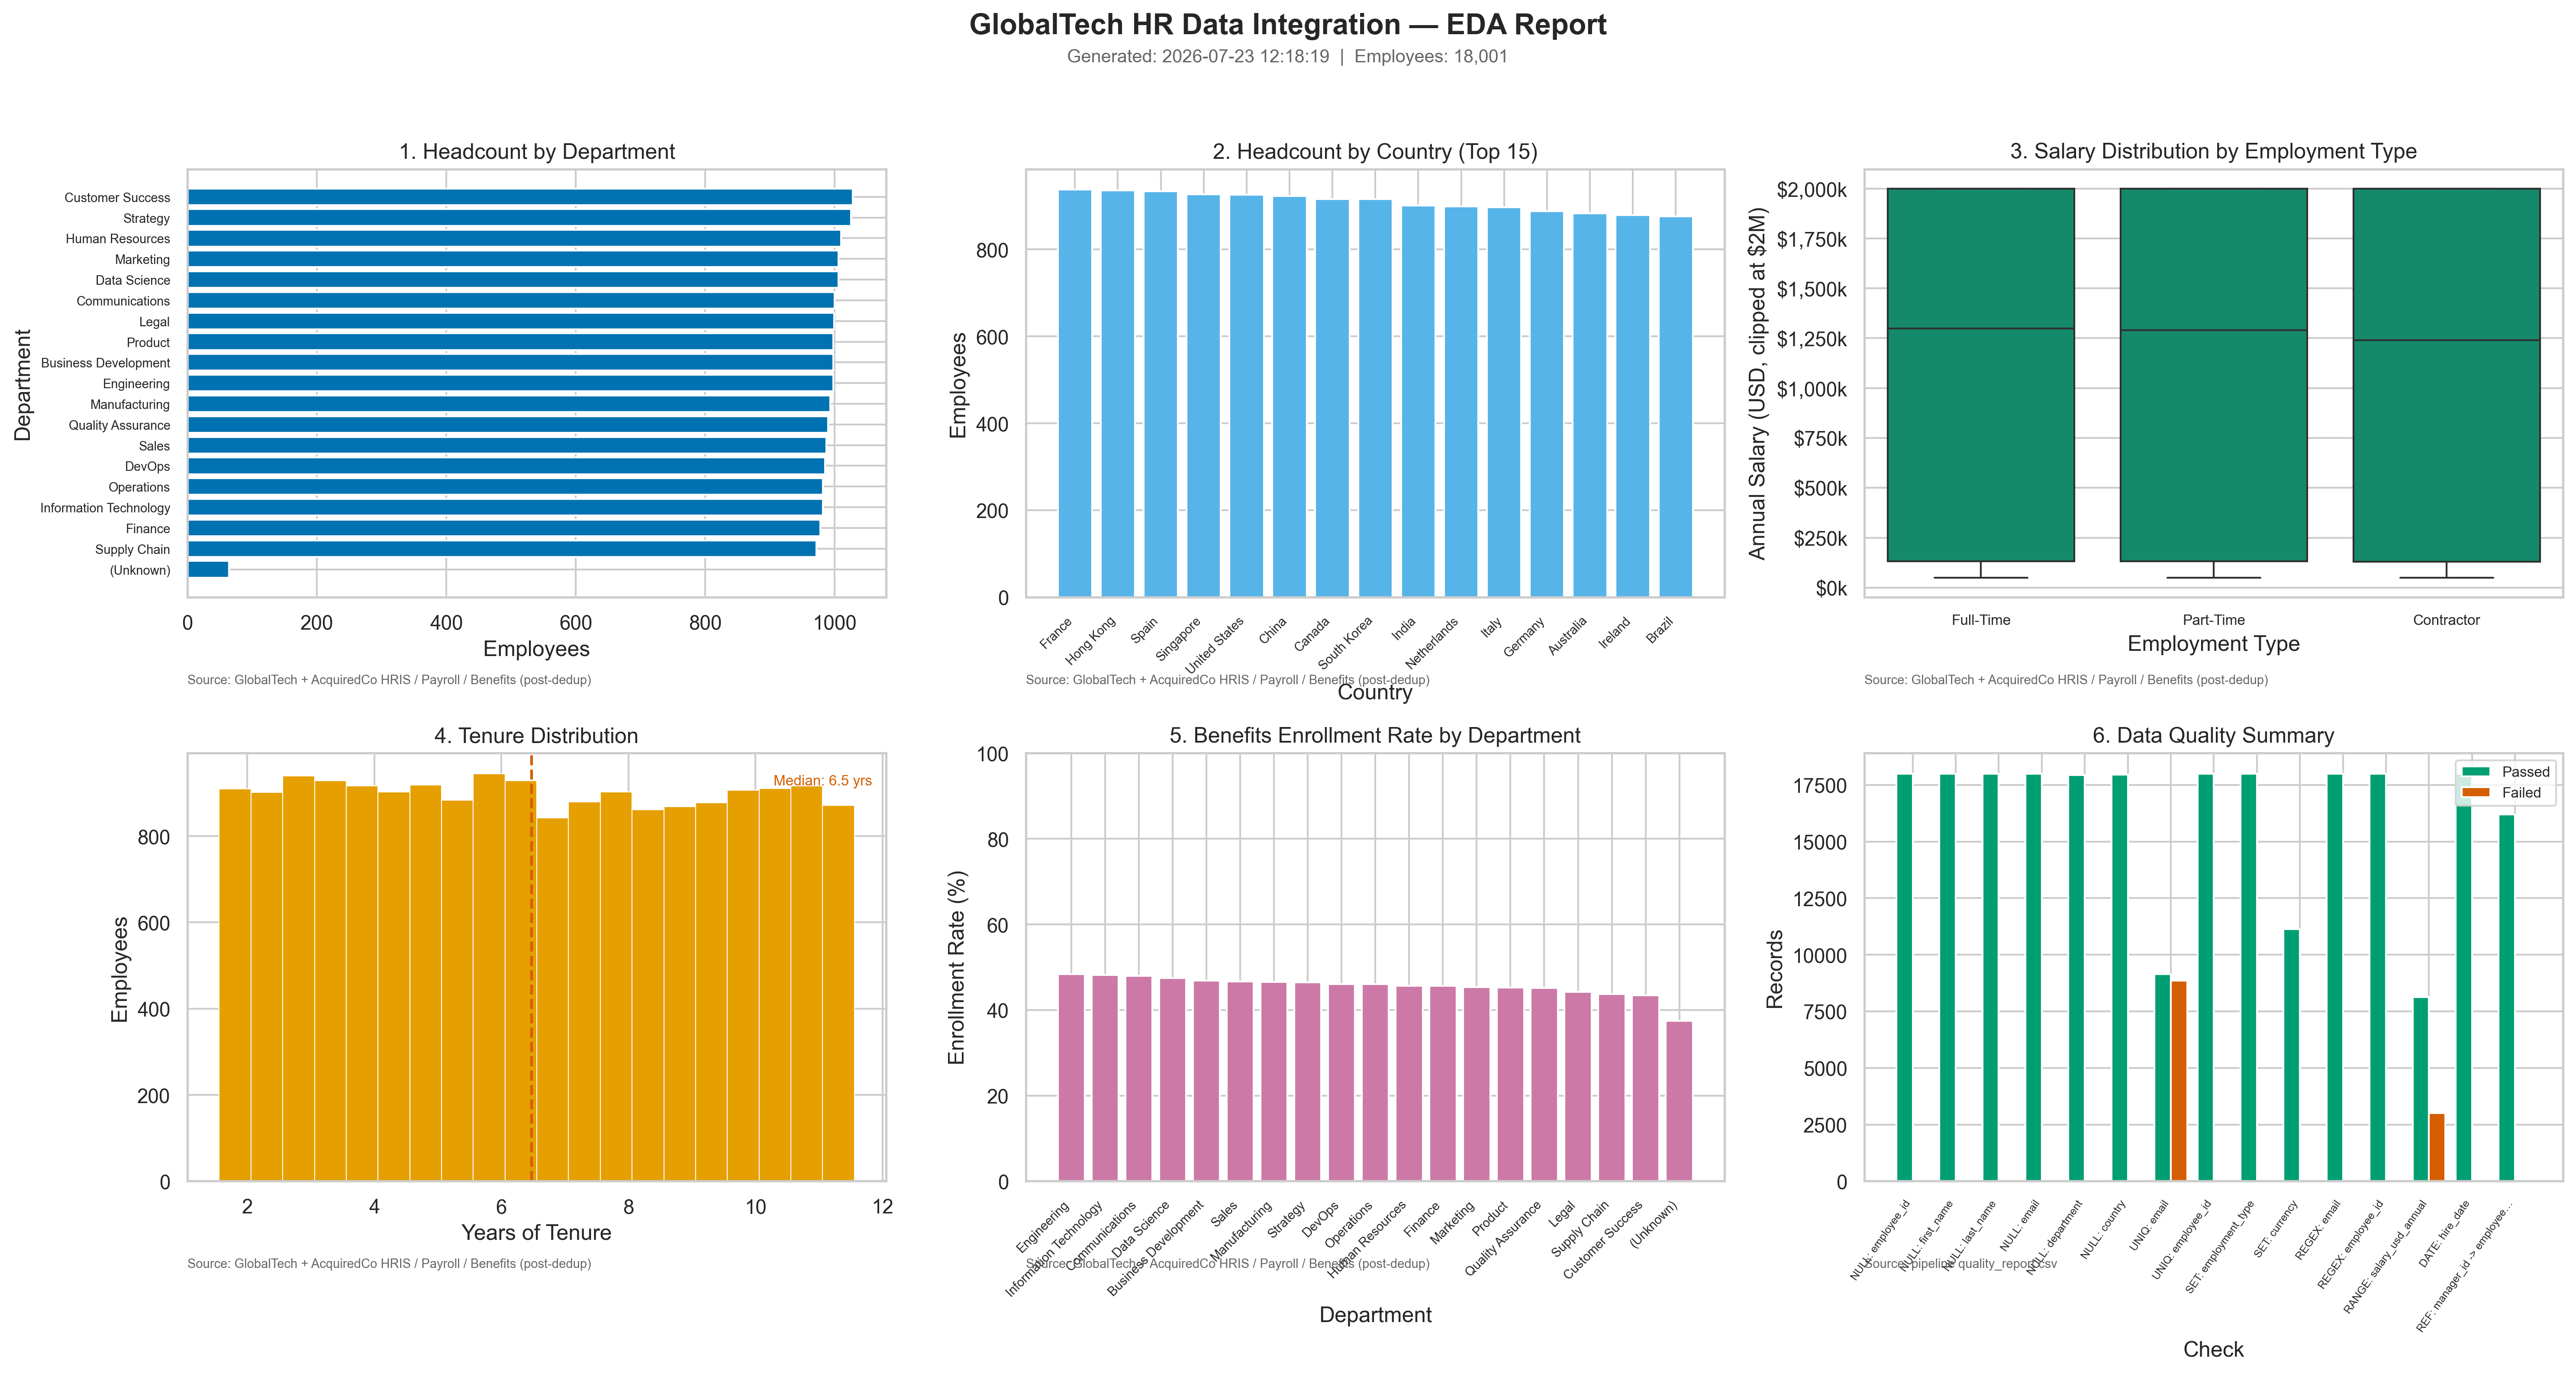

In [33]:
# Deliverable 5: six-chart EDA report (300 DPI PNG)
eda_path = generate_eda_report(employees, quality_report)
print(eda_path)
print(f"File size: {eda_path.stat().st_size / 1_000_000:.2f} MB")
Image(filename=str(eda_path), width=1100)

In [34]:
# EDA checkpoint
print(f"EDA report: {CONFIG['output_files']['eda_report']}")
print(f"Resolution: {CONFIG['eda_dpi']} DPI")
print("Charts: department, country, salary, tenure, benefits enrollment, quality summary")
print("Next: golden Parquet export and schema documentation")

EDA report: /Users/amalitech-pc-10512/Documents/GitHub/DE-upskill/sk1-capstone/data/processed/hr_eda_report.png
Resolution: 300 DPI
Charts: department, country, salary, tenure, benefits enrollment, quality summary
Next stage: golden dataset export and README documentation


In [ ]:
# Deliverable 6: golden Parquet + schema doc + review CSV refresh
export_paths = export_final_artifacts(employees, ghosts, probable_matches)
export_paths

In [ ]:
# Golden dataset partitions and schema sample
golden_root = CONFIG["output_files"]["golden_dataset"]
partition_dirs = sorted(p.name for p in golden_root.glob("company_origin=*") if p.is_dir())
print("Partitions:", partition_dirs)

golden = pd.read_parquet(golden_root)
display(
    golden.groupby("company_origin", dropna=False)
    .size()
    .rename("employees")
    .reset_index()
)

schema = build_schema_frame(employees)
schema.head(12)

In [ ]:
# Ghost + probable-match required columns
ghost_preview = pd.read_csv(CONFIG["output_files"]["ghost_employees"])
probable_preview = pd.read_csv(CONFIG["output_files"]["probable_matches"])

required_ghost = ["payroll_employee_id", "name", "salary_usd_annual", "ghost_flag_reason"]
required_probable = [
    "record_1_id",
    "record_2_id",
    "similarity_score",
    "hire_date_diff_days",
    "recommended_action",
]

print("Ghost rows:", len(ghost_preview), "| required columns present:", set(required_ghost) <= set(ghost_preview.columns))
print("Probable rows:", len(probable_preview), "| required columns present:", set(required_probable) <= set(probable_preview.columns))
display(ghost_preview.head() if not ghost_preview.empty else ghost_preview)
display(probable_preview[required_probable].head(10))

In [ ]:
# Pipeline complete
print(f"Golden dataset: {CONFIG['output_files']['golden_dataset']}")
print(f"Schema doc:     {CONFIG['output_files']['schema_doc']}")
print(f"Ghost report:   {CONFIG['output_files']['ghost_employees']}")
print(f"Probable match: {CONFIG['output_files']['probable_matches']}")
print(f"Quality report: {CONFIG['output_files']['quality_report_csv']}")
print(f"EDA report:     {CONFIG['output_files']['eda_report']}")
print(f"README:         {PROJECT_ROOT / 'README.md'}")
print("All six deliverables are available from python3 pipeline.py")